In this notebook other datasets are analysed and checked for their possible use in the project.

In [69]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

In [70]:
taxi_data = pl.read_parquet('../data/01_cleaned_data.parquet')

print(f'Taxi data shape: {taxi_data.shape[0]} rows, {taxi_data.shape[1]} columns')
display(taxi_data.head(2))

Taxi data shape: 12701771 rows, 38 columns


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",f64,f64,f64,f64,f64,f64
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00 CDT,2026-05-01 00:06:38 CDT,6m 38s,1.16,1.7031e10,1.7031e10,32.0,8.0,6.75,2.0,0.0,1.0,10.25,"""credit card""","""blue ribbon taxi association""",41.878866,-87.625192,41.899602,-87.633308,10.492462,0,5,5,2026-05-01,false,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-04-27 00:00:00 CDT,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025
"""ec94d6d233061d415f0c89cb9222e9…","""b3ee94a13b61037620cbbfc6a4a106…",2026-05-01 00:00:00 CDT,2026-05-01 00:13:00 CDT,13m,2.0,1.7031e10,1.7032e10,8.0,28.0,9.5,4.0,0.0,2.0,15.5,"""credit card""","""transit administrative center …",41.899602,-87.633308,41.874005,-87.663518,9.230769,0,5,5,2026-05-01,false,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-04-27 00:00:00 CDT,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025


In [71]:
taxi_data.dtypes

[String,
 String,
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Duration(time_unit='ms'),
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 String,
 String,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Int8,
 Int8,
 Int8,
 Date,
 Boolean,
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64]

# Holidays
There are different type of holidays in the US, which affect different workgroups. 
- City Holidays: Local services of the city
- State Holidays: State government
- Bank Holidays: Money and Mail
- Corporate Holidays: Private sector

As different groups take different taxi rides, it is relevant to differentiate between the holiday type. Further it is necessary to divide between the work days. Through mobile working and new trends the trip behavior is most likely influenced, e.g. more people work from home in the beginning and ending of the week, also the behavior differs saturdays and sundays.

As the python native holiday package does not support all of them, we decided to use a different source for the holiday data including the day of the week: [Source: https://www.workingdays.us/mobile_home.php](https://www.workingdays.us/mobile_home.php)

## Preprocessing of holiday data
Dropping irrelevant columns, incomplete records and then casting boolean to be an integer.

In [72]:
## Preprocessing of holiday data
holiday_data = pl.read_excel("../data/chicago_holidays.xlsx", sheet_name="Calendar")

# Cleanup
holiday_data = holiday_data.drop(['HolidayName', 'HolidaySources', 'BankHolidayName', 
                           'CorporateHolidayName', 'CityHolidayName', 'StateHolidayName', 
                           'DayType'])

# Missing values
print(f"Length before dropping nulls: {len(holiday_data)}")
holiday_data = holiday_data.drop_nulls()
print(f"Length after dropping nulls: {len(holiday_data)}")

# Casting
holiday_data = holiday_data.with_columns(
    pl.col("Date").str.to_date(format="%d.%m.%Y"),
    (pl.col(["BankHoliday", "CorporateHoliday", "CityHoliday", "StateHoliday"])
     .str.to_lowercase() == "true")
     .cast(pl.Int8)
)

#Dummy encoding
holiday_data = holiday_data.to_dummies(columns=["DayOfWeek"], drop_first=True)

holiday_data.head(3)

Length before dropping nulls: 852
Length after dropping nulls: 852


Date,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday
date,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8
2024-01-01,0,0,0,0,0,0,1,1,1,1
2024-01-02,0,0,0,0,1,0,0,0,0,0
2024-01-03,0,0,0,0,0,1,0,0,0,0


## Merging holiday data into taxi data
Holiday/weekday data are merged into the taxi data based on the day when the trip starts. There is also the possibility in which the trip ends on a different day but as seen below this is very unlikely. To reduce training time and prevent additional resource consumption we decided to merge only on the start day.

In [73]:
# Check taxi data on how many records begin and end on different days
taxi_data = taxi_data.with_columns(
    pl.when(pl.col("trip_start").dt.date() != pl.col("trip_end").dt.date())
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .alias("different_days"),
)

# value counts different_days
print(f'Number of records with different pickup and drop-off days:\n{taxi_data["different_days"].value_counts()}')

# Percentage of value counts
different_days_percentage = taxi_data["different_days"].value_counts(normalize=True)
print(f'Percentage of records with different pickup and drop-off days:\n{different_days_percentage}')

taxi_data = taxi_data.drop("different_days")

Number of records with different pickup and drop-off days:
shape: (2, 2)
┌────────────────┬──────────┐
│ different_days ┆ count    │
│ ---            ┆ ---      │
│ i32            ┆ u32      │
╞════════════════╪══════════╡
│ 1              ┆ 46208    │
│ 0              ┆ 12655563 │
└────────────────┴──────────┘
Percentage of records with different pickup and drop-off days:
shape: (2, 2)
┌────────────────┬────────────┐
│ different_days ┆ proportion │
│ ---            ┆ ---        │
│ i32            ┆ f64        │
╞════════════════╪════════════╡
│ 1              ┆ 0.003638   │
│ 0              ┆ 0.996362   │
└────────────────┴────────────┘


In [74]:
taxi_data.head(3)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",f64,f64,f64,f64,f64,f64
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00 CDT,2026-05-01 00:06:38 CDT,6m 38s,1.16,1.7031e10,1.7031e10,32.0,8.0,6.75,2.0,0.0,1.0,10.25,"""credit card""","""blue ribbon taxi association""",41.878866,-87.625192,41.899602,-87.633308,10.492462,0,5,5,2026-05-01,false,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-04-27 00:00:00 CDT,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025
"""ec94d6d233061d415f0c89cb9222e9…","""b3ee94a13b61037620cbbfc6a4a106…",2026-05-01 00:00:00 CDT,2026-05-01 00:13:00 CDT,13m,2.0,1.7031e10,1.7032e10,8.0,28.0,9.5,4.0,0.0,2.0,15.5,"""credit card""","""transit administrative center …",41.899602,-87.633308,41.874005,-87.663518,9.230769,0,5,5,2026-05-01,false,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-04-27 00:00:00 CDT,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025
"""e4d6e70bb24a040d511144a0b9f827…","""137d4f780c3823fdc5f26cec160a8c…",2026-05-01 00:00:00 CDT,2026-05-01 00:02:26 CDT,2m 26s,0.41,1.7032e10,1.7032e10,28.0,28.0,8.5,1.2,0.0,0.0,10.2,"""mobile""","""5 star taxi""",41.874005,-87.663518,41.874005,-87.663518,10.109589,0,5,5,2026-05-01,false,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-04-27 00:00:00 CDT,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025


In [75]:
# Convert both dates to the same column so they are mergable - type date
taxi_data = taxi_data.with_columns(
    pl.col("trip_start").dt.date().alias("date_day")
)
holiday_data = holiday_data.rename({"Date": "date_day"})


# Merge holiday/weekday data into taxi data
taxi_data = taxi_data.join(
    holiday_data,
    on="date_day",
    how="left",
    suffix="_tStart"
)
# .drop("date_day")

display(taxi_data.head())
del holiday_data

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,date_day,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",f64,f64,f64,f64,f64,f64,date,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00 CDT,2026-05-01 00:06:38 CDT,6m 38s,1.16,1.7031e10,1.7031e10,32.0,8.0,6.75,2.0,0.0,1.0,10.25,"""credit card""","""blue ribbon taxi association""",41.878866,-87.625192,41.899602,-87.633308,10.492462,0,5,5,2026-05-01,false,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-04-27 00:00:00 CDT,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025,2026-05-01,1,0,0,0,0,0,0,0,0,0
"""ec94d6d233061d415f0c89cb9222e9…","""b3ee94a13b61037620cbbfc6a4a106…",2026-05-01 00:00:00 CDT,2026-05-01 00:13:00 CDT,13m,2.0,1.7031e10,1.7032e10,8.0,28.0,9.5,4.0,0.0,2.0,15.5,"""credit card""","""transit administrative center …",41.899602,-87.633308,41.874005,-87.663518,9.230769,0,5,5,2026-05-01,false,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-04-27 00:00:00 CDT,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025,2026-05-01,1,0,0,0,0,0,0,0,0,0
"""e4d6e70bb24a040d511144a0b9f827…","""137d4f780c3823fdc5f26cec160a8c…",2026-05-01 00:00:00 CDT,2026-05-01 00:02:26 CDT,2m 26s,0.41,1.7032e10,1.7032e10,28.0,28.0,8.5,1.2,0.0,0.0,10.2,"""mobile""","""5 star taxi""",41.874005,-87.663518,41.874005,-87.663518,10.109589,0,5,5,2026-05-01,false,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-04-27 00:00:00 CDT,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025,2026-05-01,1,0,0,0,0,0,0,0,0,0
"""e3aa4f40022e5b2151ee837990c103…","""e168baf6e4ae34f44dd0fe4181d53c…",2026-05-01 00:00:00 CDT,2026-05-01 00:25:25 CDT,25m 25s,18.54,1.7032e10,1.7031e10,76.0,32.0,45.5,5.0,0.0,5.0,56.0,"""credit card""","""sun taxi""",41.980264,-87.913625,41.878866,-87.625192,43.766557,0,5,5,2026-05-01,false,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-04-27 00:00:00 CDT,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025,2026-05-01,1,0,0,0,0,0,0,0,0,0
"""d06eddc331367e8282eb138f0a0157…","""f1ed053acb7ee562f935ec06608787…",2026-05-01 00:00:00 CDT,2026-05-01 00:19:21 CDT,19m 21s,11.41,1.7032e10,1.7031e10,76.0,14.0,29.25,0.0,0.0,0.0,29.25,"""cash""","""chicago independents""",41.980264,-87.913625,41.968069,-87.721559,35.379845,0,5,5,2026-05-01,false,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,2026-04-27 00:00:00 CDT,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025,2026-05-01,1,0,0,0,0,0,0,0,0,0


# Events
Events are typical destination for and also from Taxi trips. It is expected that not all people travel by public transport or their own cars to concerts, sports matches and other events. The city of Chicago offers a list of such events including their coordinates: https://data.cityofchicago.org/Events/Special-Events/xgse-8eg7/about_data.

The data offers the ward in which the event is taking place as well as the exact location. Further the start time is given.

In [76]:
event_data = pl.read_csv("../data/chicago_events_20260515.csv", null_values=["", "N/A", "NA", "NaN"])
event_data = event_data.drop(['Venue', ])

display(event_data.head(2))

Date,Venue Address,Event Type,Event Details,Start Time,Ward,Location
str,str,str,str,str,str,str
"""11/21/2025""","""50 W. Washington Street""","""Special Event""","""Christkindlmarket - Chicago""","""11:00AM""","""42""","""POINT (-87.6302 41.88325)"""
"""11/22/2025""","""50 W. Washington Street""","""Special Event""","""Christkindlmarket - Chicago""","""11:00AM""","""42""","""POINT (-87.6302 41.88325)"""


In [77]:
display(event_data.null_count())

Date,Venue Address,Event Type,Event Details,Start Time,Ward,Location
u32,u32,u32,u32,u32,u32,u32
0,0,0,1,286,0,16


Over half of the event data have missing values, therefore it is difficult to map the individual event records to matching timeframes. We decided <b>against</b> merging the event data into the texi data because of the high incompleteness of the data. Further the affected number of trips may be low as the time and the location have to match.

# Open Meteo Weather Data
Following data source provides weather data within chicago at an hourly rate instead of the daily rate provided by the sampling. We take into account that the temperature is different within the city but generally it is expected to change throughout the day more or less evenly. Using a hourly sample rate enables to use day and night temperature influences for later models.

Source:
https://open-meteo.com/en/docs/historical-weather-api?latitude=41.85&longitude=-87.65&hourly=temperature_2m,rain,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,apparent_temperature,relative_humidity_2m,snow_depth,snowfall&daily=temperature_2m_max,temperature_2m_min&start_date=2024-01-01

In [78]:
# This code block is adapted by the Open Meteo Weather Website
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 41.85,
	"longitude": -87.65,
	"start_date": "2024-01-01",
	"end_date": "2026-05-11",
	"daily": ["temperature_2m_max", "temperature_2m_min"],
	"hourly": ["temperature_2m", "rain", "precipitation", "wind_speed_10m", "wind_direction_10m", "wind_gusts_10m", "apparent_temperature", "relative_humidity_2m", "snow_depth", "snowfall"],
	"timezone": "America/Chicago",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_rain = hourly.Variables(1).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(2).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(3).ValuesAsNumpy()
hourly_wind_direction_10m = hourly.Variables(4).ValuesAsNumpy()
hourly_wind_gusts_10m = hourly.Variables(5).ValuesAsNumpy()
hourly_apparent_temperature = hourly.Variables(6).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(7).ValuesAsNumpy()
hourly_snow_depth = hourly.Variables(8).ValuesAsNumpy()
hourly_snowfall = hourly.Variables(9).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	).tz_convert(response.Timezone().decode())
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["rain"] = hourly_rain
hourly_data["precipitation"] = hourly_precipitation
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["wind_direction_10m"] = hourly_wind_direction_10m
hourly_data["wind_gusts_10m"] = hourly_wind_gusts_10m
hourly_data["apparent_temperature"] = hourly_apparent_temperature
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["snow_depth"] = hourly_snow_depth
hourly_data["snowfall"] = hourly_snowfall

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data:\n")
display(hourly_dataframe.head(2))

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(1).ValuesAsNumpy()

daily_data = {
	"date": pd.date_range(
		start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = daily.Interval()),
		inclusive = "left"
	).tz_convert(response.Timezone().decode()).normalize()
}

daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min

daily_dataframe = pd.DataFrame(data = daily_data)
print("\nDaily data:")
display(daily_dataframe.head(2))

Coordinates: 41.8629150390625°N -87.64877319335938°E
Elevation: 179.0 m asl
Timezone: b'America/Chicago'b'GMT-5'
Timezone difference to GMT+0: -18000s

Hourly data:



,date,temperature_2m,rain,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,apparent_temperature,relative_humidity_2m,snow_depth,snowfall
0,2023-12-31 23:00:00-06:00,0.55,0.0,0.1,30.449274,335.556061,45.719997,-6.27078,84.567177,0.01,0.07
1,2024-01-01 00:00:00-06:00,0.35,0.0,0.1,30.449274,335.556061,44.279999,-6.48454,85.168861,0.01,0.07



Daily data:


,date,temperature_2m_max,temperature_2m_min
0,2023-12-31 00:00:00-06:00,1.35,-2.6
1,2024-01-01 00:00:00-06:00,2.50,-4.6


## Merge daily into hourly data set

In [79]:
# Convert to polars and merge on the day of the hourly data record
hourly_for_merge = pl.from_pandas(hourly_dataframe).with_columns(
    pl.col("date").dt.strftime("%Y-%m-%d").alias("date_day")
)

daily_for_merge = pl.from_pandas(daily_dataframe).with_columns(
    pl.col("date").dt.strftime("%Y-%m-%d").alias("date_day")
)

weather_data = hourly_for_merge.join(
    daily_for_merge.drop("date"),
    on="date_day",
    how="left"
).drop("date_day")

del hourly_for_merge
del daily_for_merge

display(weather_data.head(1))

date,temperature_2m,rain,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,apparent_temperature,relative_humidity_2m,snow_depth,snowfall,temperature_2m_max,temperature_2m_min
"datetime[ms, America/Chicago]",f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
2023-12-31 23:00:00 CST,0.55,0.0,0.1,30.449274,335.556061,45.719997,-6.27078,84.567177,0.01,0.07,1.35,-2.6


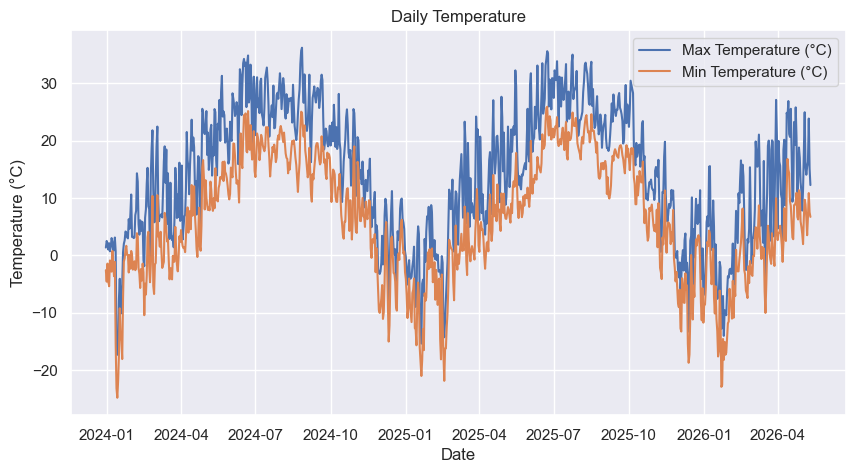

In [80]:
# plot daily weather data
plt.figure(figsize = (10, 5))
plt.plot(daily_dataframe["date"], daily_dataframe["temperature_2m_max"], label = "Max Temperature (°C)")
plt.plot(daily_dataframe["date"], daily_dataframe["temperature_2m_min"], label = "Min Temperature (°C)")
plt.title("Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

## Plot all features over time

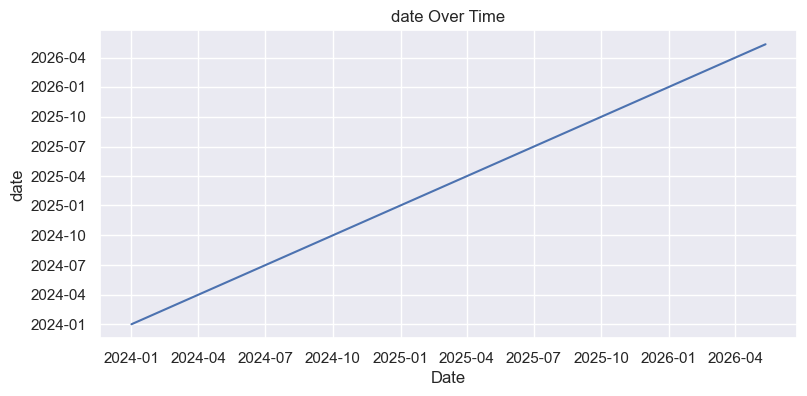

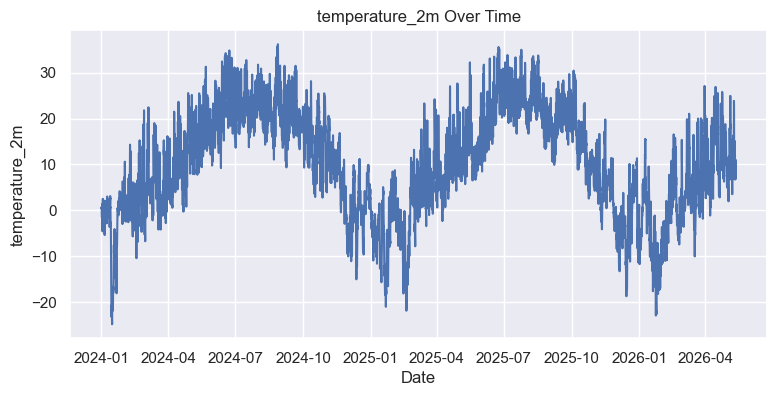

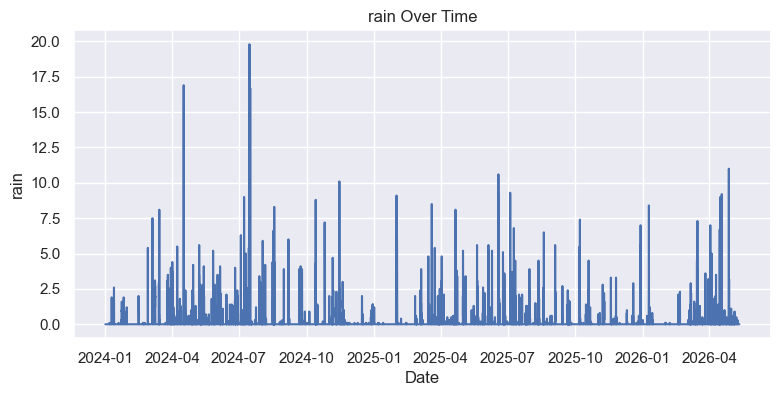

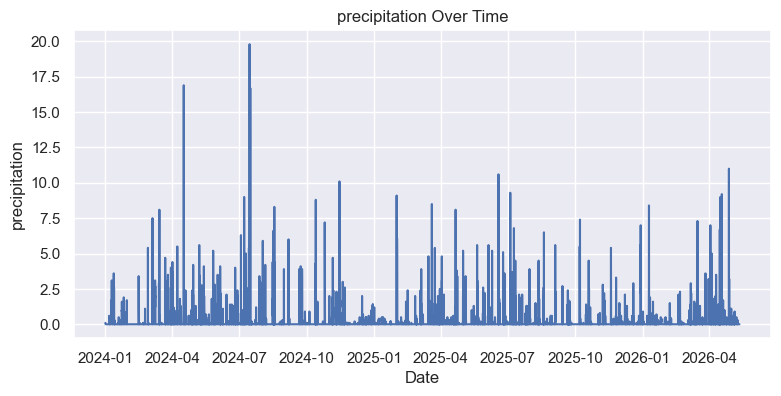

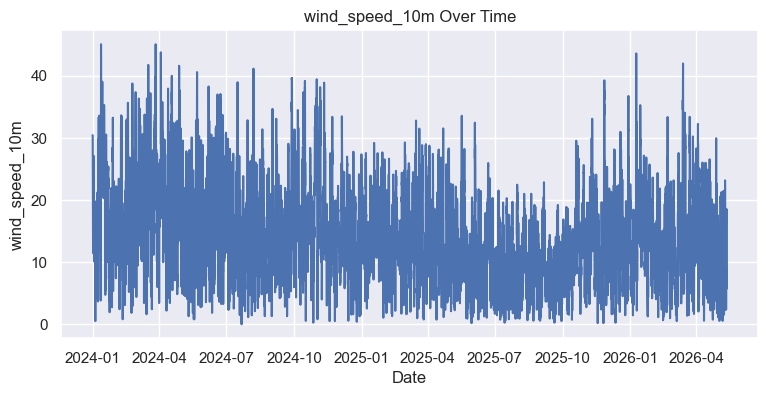

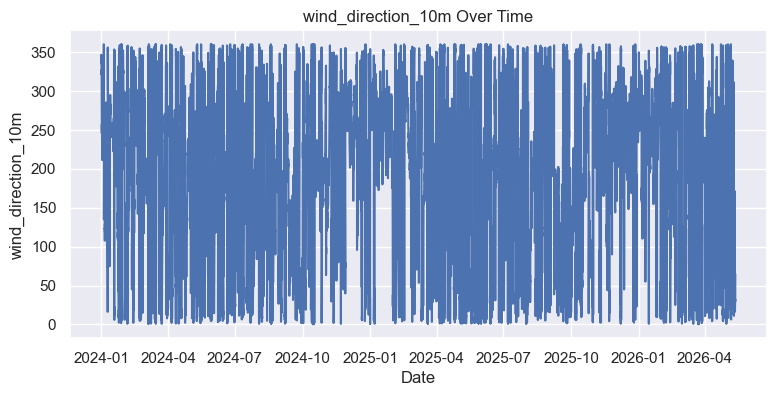

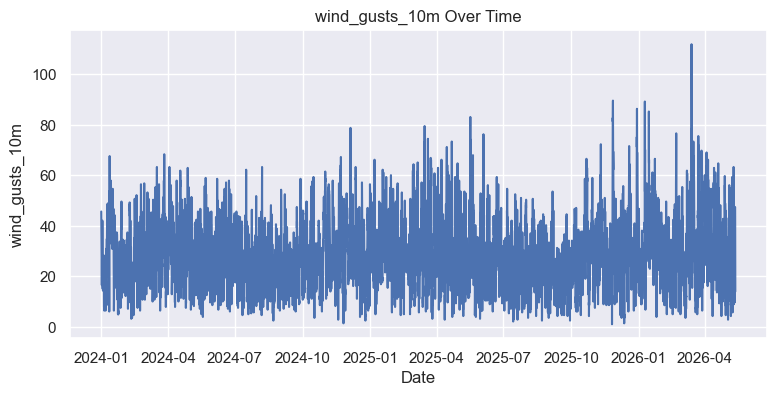

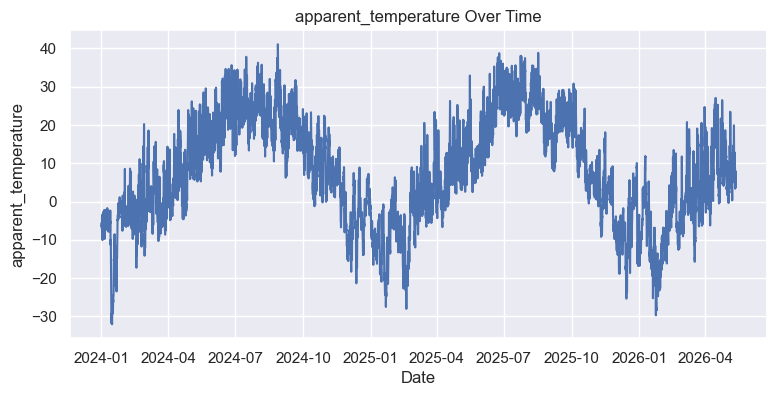

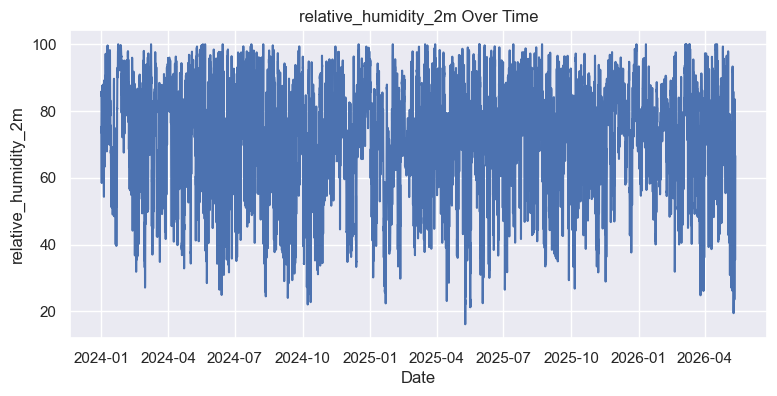

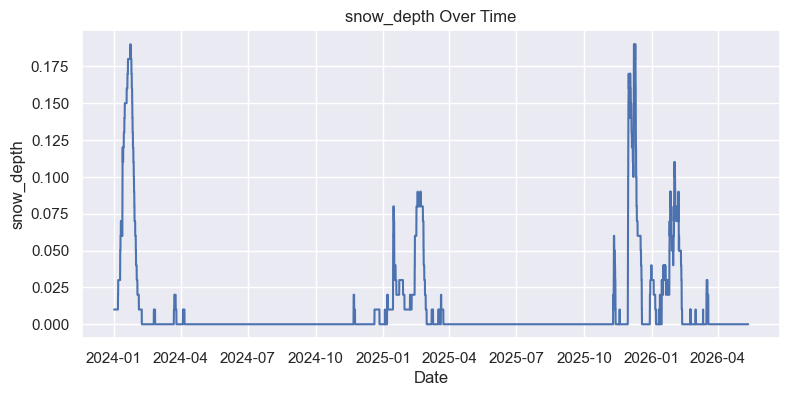

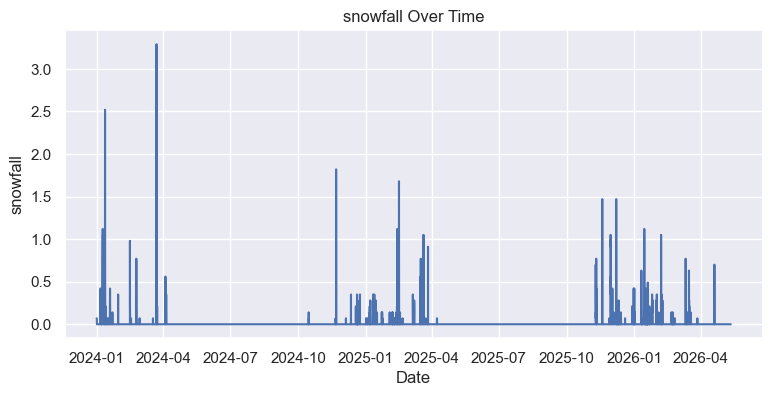

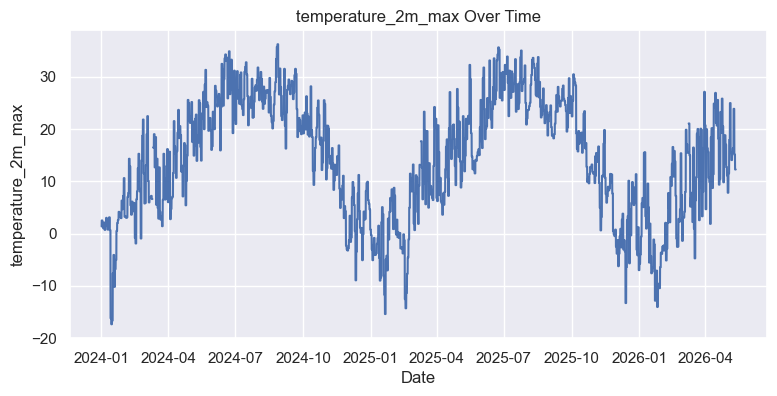

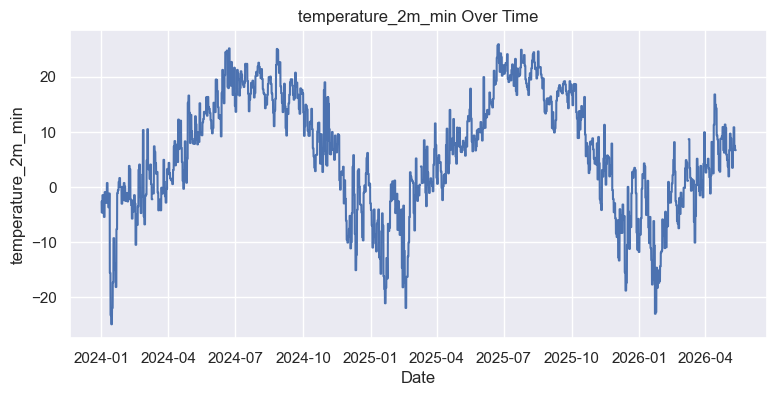

In [81]:
# feature over time
for column in weather_data.columns:
    plt.figure(figsize=(9, 4))
    plt.plot(weather_data['date'], weather_data[column])
    plt.xlabel('Date')
    plt.ylabel(column)
    plt.title(f'{column} Over Time')
    plt.show()

## Missing values
Below you can see that after the merger 69 records have missing daily values due to the merger. You can see that three days are missing. In case the two daily weather columns/features are irrelevant during the prediction, the two columns can be dropped, otherwise the incomplete 69 records are dropped for now.

In [82]:
print('Number of missing values per column:')
display(weather_data.null_count())
print('\n')

# Show the date of when the records are incomplete
incomplete_dates = weather_data.filter(
    pl.col("temperature_2m").is_null() | pl.col("temperature_2m_max").is_null() | pl.col("temperature_2m_min").is_null()
).select(pl.col("date").dt.date().alias("date_day")).unique()
print('Dates of which the daily data is missing:')
display(incomplete_dates)

Number of missing values per column:


date,temperature_2m,rain,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,apparent_temperature,relative_humidity_2m,snow_depth,snowfall,temperature_2m_max,temperature_2m_min
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,69,69




Dates of which the daily data is missing:


date_day
date
2025-03-09
2024-03-10
2026-03-08


In [83]:
incomplete_weather_records = weather_data.filter(
    pl.col("temperature_2m_max").is_null() & pl.col("temperature_2m_min").is_null()
)
print("Number of records missing both, min and max temperature of the day:", incomplete_weather_records.height)

Number of records missing both, min and max temperature of the day: 69


In [84]:
print('Number of weather records before dropping nulls:', weather_data.height)
weather_data = weather_data.drop_nulls()
print('Number of weather records after dropping nulls:', weather_data.height)

Number of weather records before dropping nulls: 20738
Number of weather records after dropping nulls: 20669


## Merge date into taxi-data
Relevant are the two timestamp columns for the merger. Since the weather data is hourly we can truncate both datasets timestamps to an hour and join it based on this truncated timestamp.

In [85]:
taxi_data = taxi_data.with_columns(
    pl.col("trip_start").dt.truncate("1h").alias("weather_hour")
).sort("weather_hour")
weather_data = (
    weather_data.with_columns(
        pl.col("date").dt.truncate("1h").alias("weather_hour")
    )
    .sort("weather_hour")
)
merged_data = taxi_data.join(
    weather_data,
    on="weather_hour",
    how="left",
)

del weather_data

# merged_data = merged_data.drop('date_right')
display(merged_data.head(1))

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,date_day,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,weather_hour,date_right,temperature_2m,rain,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,apparent_temperature,relative_humidity_2m,snow_depth,snowfall,temperature_2m_max,temperature_2m_min
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",f64,f64,f64,f64,f64,f64,date,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""ff4d916013cd671c8ec9dcb181a3ef…","""0ccfc1f0f221ef68515db370201623…",2024-01-01 00:45:00 CST,2024-01-01 01:07:00 CST,22m,15.0,1.7032e10,1.7031e10,76.0,8.0,38.25,8.55,0.0,4.0,50.8,"""credit card""","""choice taxi association""",41.980264,-87.913625,41.899602,-87.633308,40.909091,0,1,1,2024-01-01,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.781831,0.62349,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.35,0.0,0.1,30.449274,335.556061,44.279999,-6.48454,85.168861,0.01,0.07,2.5,-4.6


Below you can see the time differences of the trip_start to the timestamp of the weather (renamed by the join to date_right). The results are very good and the maximum is below an hour.

In [86]:
merged_data = merged_data.with_columns(
    (pl.col("trip_start") - pl.col("date_right")).abs().alias("delta_time")
).drop("date_right")

delta_stats = merged_data.select(
    pl.col("delta_time").min().alias("min"),
    pl.col("delta_time").max().alias("max"),
    pl.col("delta_time").mean().alias("mean"),
).row(0)

print(f"Minimum time difference: {delta_stats[0]}")
print(f"Maximum time difference: {delta_stats[1]}")
print(f"Average time difference: {delta_stats[2]}")


Minimum time difference: 0:00:00
Maximum time difference: 0:45:00
Average time difference: 0:22:30.659000


There are still missing values by the original taxi data but the three days which miss the daily weather data affect around 31 thousand records.

In [87]:
# calculate number of nulls in merged data
print('Number of missing values per column in merged data:')
display(merged_data.null_count())

missing_weather_dates = merged_data.filter(
    pl.col("temperature_2m").is_null() | pl.col("temperature_2m_max").is_null() | pl.col("temperature_2m_min").is_null()
).select(pl.col("weather_hour").dt.date().alias("date_day")).unique()
print("Days where weather data is missing:")
display(missing_weather_dates)

incomplete_weather_records = merged_data.filter(
    pl.col("temperature_2m_max").is_null() & pl.col("temperature_2m_min").is_null()
)
print("Daily missing weather data causes on the three days the following number of records to be incomplete:", incomplete_weather_records.height)

Number of missing values per column in merged data:


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,date_day,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,weather_hour,temperature_2m,rain,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,apparent_temperature,relative_humidity_2m,snow_depth,snowfall,temperature_2m_max,temperature_2m_min,delta_time
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,918443,1343,1002500,0,0,0,0,0,0,0,0,0,932145,932145,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,31155,31155,31155,31155,31155,31155,31155,31155,31155,31155,31155,31155,31155


Days where weather data is missing:


date_day
date
2024-03-10
2025-03-09
2026-03-08


Daily missing weather data causes on the three days the following number of records to be incomplete: 31155


Lastly, belows plot shows the distribution the average delta time over the whole timeframe of the taxi dataset.

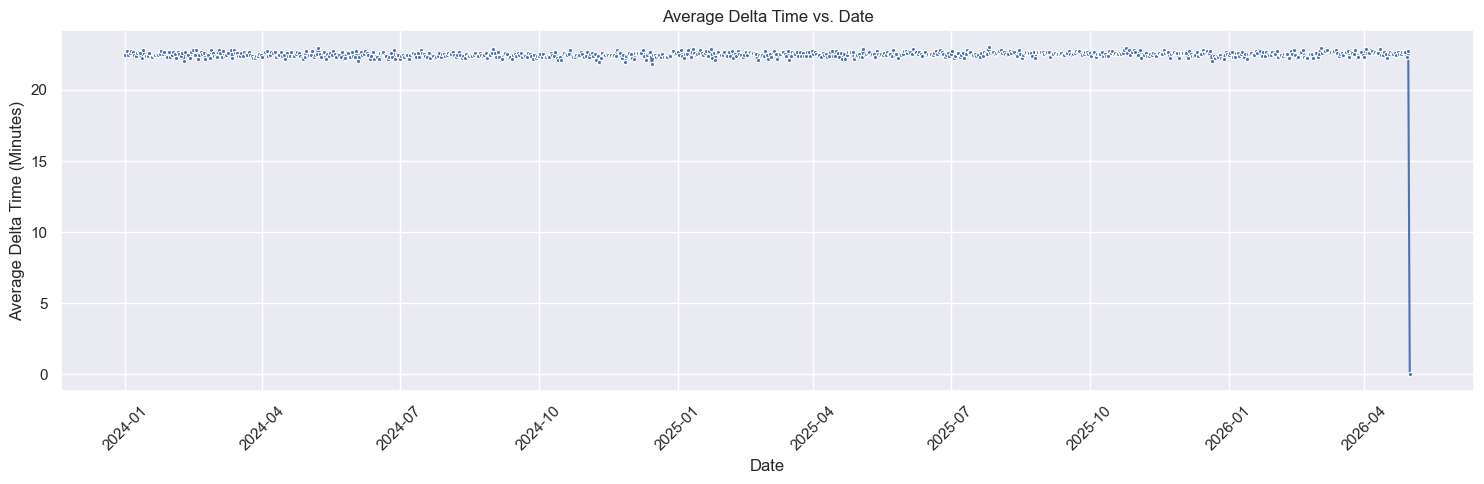

In [88]:
# Prompt: I want to plot a diagram for my two columns in my polars dataframe merged_data. x axis columns should be date day of type datetime64[ms]. y axis column should be avg_delta_time_minutes of type float64
plot_data = (
    merged_data.with_columns(
        pl.col("delta_time").dt.total_minutes().alias("delta_time_minutes"), # convert to minutes
        pl.col("trip_start").dt.date().alias("date_day"),
    )
    .group_by("date_day")
    .agg(pl.col("delta_time_minutes").mean().alias("avg_delta_time_minutes"))
    .sort("date_day")
    .to_pandas()
)

sns.set_theme(style="darkgrid")

plt.figure(figsize=(15, 5))

# Seaborn can natively take Polars series
sns.lineplot(
    x=plot_data["date_day"], 
    y=plot_data["avg_delta_time_minutes"],
    marker="o",
    markersize=3
)

plt.xlabel("Date")
plt.ylabel("Average Delta Time (Minutes)")
plt.title("Average Delta Time vs. Date")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Cleanup and export

In [89]:
merged_data = merged_data.drop(['delta_time', 'date', 'weather_hour'])
merged_data.head(5)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,date_day,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,temperature_2m,rain,precipitation,wind_speed_10m,wind_direction_10m,wind_gusts_10m,apparent_temperature,relative_humidity_2m,snow_depth,snowfall,temperature_2m_max,temperature_2m_min
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",f64,f64,f64,f64,f64,f64,date,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""ff4d916013cd671c8ec9dcb181a3ef…","""0ccfc1f0f221ef68515db370201623…",2024-01-01 00:45:00 CST,2024-01-01 01:07:00 CST,22m,15.0,1.7032e10,1.7031e10,76.0,8.0,38.25,8.55,0.0,4.0,50.8,"""credit card""","""choice taxi association""",41.980264,-87.913625,41.899602,-87.633308,40.909091,0,1,1,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.781831,0.62349,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.1,30.449274,335.556061,44.279999,-6.48454,85.168861,0.01,0.07,2.5,-4.6
"""031c6a339f8b92f0cd71d93503c1f4…","""0fdab9be71f6d88e3d3a2e115afc5a…",2024-01-01 00:45:00 CST,2024-01-01 01:31:59 CST,46m 59s,5.94,1.7031e10,1.7032e10,32.0,3.0,26.75,0.0,0.0,1.0,28.25,"""credit card""","""city service""",41.878866,-87.625192,41.965812,-87.655879,7.585669,0,1,1,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.781831,0.62349,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.1,30.449274,335.556061,44.279999,-6.48454,85.168861,0.01,0.07,2.5,-4.6
"""0852ba909d47fda572bf5cfd6f7534…","""50e6045759886233d0e834d9877f52…",2024-01-01 00:45:00 CST,2024-01-01 01:41:00 CST,56m,0.8,1.7032e10,1.7031e10,56.0,32.0,44.25,0.0,0.0,6.0,50.25,"""cash""","""taxi affiliation services""",41.785999,-87.750934,41.884987,-87.620993,0.857143,0,1,1,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.781831,0.62349,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.1,30.449274,335.556061,44.279999,-6.48454,85.168861,0.01,0.07,2.5,-4.6
"""1181a567553667587f1df4d77e84a0…","""b56b31883524426035c290bfdbe4e0…",2024-01-01 00:45:00 CST,2024-01-01 01:10:04 CST,25m 4s,5.55,1.7031e10,1.7031e10,6.0,24.0,18.25,3.95,0.0,1.0,23.7,"""credit card""","""sun taxi""",41.944227,-87.655998,41.901207,-87.676356,13.284574,0,1,1,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.781831,0.62349,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.1,30.449274,335.556061,44.279999,-6.48454,85.168861,0.01,0.07,2.5,-4.6
"""11945be772d77429461147177bc323…","""3835dded237bfc6b12d2181ec37148…",2024-01-01 00:45:00 CST,2024-01-01 01:04:00 CST,19m,2.16,1.7031e10,1.7031e10,8.0,28.0,11.25,0.0,0.0,1.0,12.75,"""credit card""","""blue ribbon taxi association""",41.899156,-87.626211,41.879255,-87.642649,6.821053,0,1,1,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.781831,0.62349,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.1,30.449274,335.556061,44.279999,-6.48454,85.168861,0.01,0.07,2.5,-

In [90]:
merged_data.write_parquet("../data/02_merged_data.parquet")